# Part 3: Multivariate Modeling via the Semi-Parametric Cox Proportional Hazards Model

## 1.1. Theoretical Basis and Clinical Application
While non-parametric methods (such as Kaplan-Meier estimators and Log-Rank tests) allowed us to identify individual risk factors in an isolated setting, we now transition to a more complex, multivariate approach. In real-world clinical practice, factors such as tumor stage, genetic mutations (e.g., KRAS), and biomarker levels (e.g., CA 19-9) influence patient prognosis simultaneously.

The Cox Proportional Hazards Model is a semi-parametric statistical method that allows us to evaluate how multiple independent variables (covariates) jointly impact the **rate of event occurrence** (in our case, mortality from pancreatic cancer). It is termed "semi-parametric" because it makes no assumptions about the underlying shape of the baseline hazard function (unlike Weibull or Exponential models), but it assumes a parametric, exponential relationship between the covariates and the hazard.

## 1.2. Mathematical Formulation of the Model
Mathematically, the hazard $h(t | X)$ for an individual patient at time $t$, given a vector of covariates $X = (X_1, X_2, \dots, X_p)$, is defined by the following equation:

$$h(t | X) = h_0(t) \cdot \exp(\beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p)$$

Where:
* **$h(t | X)$** is the Hazard Function – the instantaneous risk of the event occurring at time $t$, given that the patient has survived up to that time.
* **$h_0(t)$** is the Baseline Hazard – the hazard for an individual where all covariates are equal to zero ($X = 0$). This function is entirely dependent on time $t$ but remains unspecified in the model, providing immense flexibility.
* **$\beta_1, \beta_2, \dots, \beta_p$** are the regression coefficients, estimated using the Partial Maximum Likelihood method.

For clinical interpretation, the effect of each predictor is expressed as a **Hazard Ratio (HR)**:

$$\text{HR} = \exp(\beta_i)$$

* If $\text{HR} > 1$, the covariate increases the hazard (shortens survival time). For instance, an advanced tumor stage is expected to yield an $\text{HR} > 1$.
* If $\text{HR} < 1$, the covariate has a protective effect (decreases the hazard).

## 1.3. The Proportional Hazards Assumption
The validity of the Cox model rests upon the fundamental assumption of **Proportional Hazards** — meaning the hazard ratio between any two individuals remains constant over time. 

For example, if the mortality risk for a patient in Stage IV is 3 times higher than for a patient in Stage I during the first month after diagnosis, this ratio ($\text{HR} = 3$) must remain identical at month 12 and month 24. Mathematically, time $t$ is isolated within the baseline hazard $h_0(t)$, while the covariate effect $\exp(X\beta)$ is multiplicative and time-independent:

$$\frac{h(t | X_A)}{h(t | X_B)} = \frac{h_0(t) e^{X_A \beta}}{h_0(t) e^{X_B \beta}} = e^{(X_A - X_B)\beta} = \text{const}$$

If this assumption is violated (i.e., the effect of a specific factor diminishes or strengthens over time), the model loses its mathematical accuracy, necessitating the use of time-varying covariates or stratified analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

In [2]:
# 1. DATA PREPARATION

data = pd.read_csv("pancreatic_cancer_dataset_cleaned.csv")

# Log transform CA_19_9
data["log_CA_19_9"] = np.log1p(data["CA_19_9_Level"])

# Numeric version of Tumor_Grade
grade_map = {
    "Grade 1 (Well Differentiated)": 1,
    "Grade 2 (Moderately Differentiated)": 2,
    "Grade 3 (Poorly Differentiated)": 3
}
data["Tumor_Grade_Num"] = data["Tumor_Grade"].map(grade_map)

# Columns to exclude
exclude_cols = ["Survival_Months", "Survived", "CA_19_9_Level", "Tumor_Grade", "Country", "Age_Group", "Five_Year_Status"]
id_date_cols = ["Patient_ID", "Diagnosis_Date"]

# Detect numeric and categorical columns
numeric_cols = []
categorical_cols = []

for col in data.columns:
    if col in exclude_cols or col in id_date_cols:
        continue
    if data[col].dtype in ["int64", "float64"]:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)

if "Tumor_Grade_Num" in data.columns and "Tumor_Grade_Num" not in numeric_cols:
    numeric_cols.append("Tumor_Grade_Num")

# Grouping of rare categories
MIN_CATEGORY_FREQ = 10
for col in categorical_cols:
    value_counts = data[col].value_counts()
    rare_values = value_counts[value_counts < MIN_CATEGORY_FREQ].index
    if len(rare_values) > 0:
        data[col] = data[col].replace(rare_values, "OTHER")

# Convert categorical to category type
for col in categorical_cols:
    data[col] = data[col].astype("category")

# Scale numeric columns
scaler = StandardScaler()
data_scaled = data.copy()
data_scaled[numeric_cols] = scaler.fit_transform(data[numeric_cols])

# Build formula
formula_parts = []
for col in categorical_cols:
    formula_parts.append(f"C({col})")
for col in numeric_cols:
    formula_parts.append(col)
formula = " + ".join(formula_parts)

print(f"Total variables: {len(formula_parts):_}")
print(f"Total patients: {len(data_scaled):_}")

Total variables: 45
Total patients: 2_000


In [3]:
# 2. GRID SEARCH WITH L1_RATIO (ELASTIC NET)

print("GRID SEARCH + STRATIFIED 5-FOLD CV\n")

# Parameters to test
penalizers = [0.01, 0.1,]
l1_ratios = [0.0, 0.5]

# Stratified KFold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=29)

best_score = 0
best_penalizer = 0.0
best_l1_ratio = 0.0
results = []

for p in penalizers:
    for l1 in l1_ratios:
        fold_scores = []
        
        for train_idx, test_idx in skf.split(data_scaled, data_scaled["Survived"]):
            train = data_scaled.iloc[train_idx]
            test = data_scaled.iloc[test_idx]
            
            # IMPORTANT: Pass both penalizer AND l1_ratio
            model = CoxPHFitter(penalizer=p, l1_ratio=l1)
            model.fit(train, duration_col="Survival_Months",
                      event_col="Survived", formula=formula, show_progress=False)
            
            risk = model.predict_partial_hazard(test)
            c_idx = concordance_index(test["Survival_Months"], -risk, test["Survived"])
            fold_scores.append(c_idx)
        
        mean_score = np.mean(fold_scores)
        std_score = np.std(fold_scores)
        results.append((p, l1, mean_score, std_score))
        print(f"penalizer={p}, l1_ratio={l1}: {mean_score:.3f} (+/- {std_score:.3f})")
        
        if mean_score > best_score:
            best_score = mean_score
            best_penalizer = p
            best_l1_ratio = l1

print(f"   BEST PARAMETERS:")
print(f"   penalizer = {best_penalizer}")
print(f"   l1_ratio = {best_l1_ratio}")
print(f"   C-index = {best_score:.3f}")

GRID SEARCH + STRATIFIED 5-FOLD CV

penalizer=0.01, l1_ratio=0.0: 0.792 (+/- 0.005)
penalizer=0.01, l1_ratio=0.5: 0.791 (+/- 0.005)
penalizer=0.1, l1_ratio=0.0: 0.784 (+/- 0.004)
penalizer=0.1, l1_ratio=0.5: 0.781 (+/- 0.007)
   BEST PARAMETERS:
   penalizer = 0.01
   l1_ratio = 0.0
   C-index = 0.792


In [4]:
# 3. WHAT L1_RATIO MEANS
print("WHAT L1_RATIO MEANS")

print("""
l1_ratio = 0.0  → Pure Ridge (L2) - all features kept, coefficients shrunk
l1_ratio = 0.5  → Elastic Net - mix of L1 and L2
l1_ratio = 1.0  → Pure Lasso (L1) - feature selection (some coefficients become 0)

Higher l1_ratio = more feature selection (sparser model)
""")

WHAT L1_RATIO MEANS

l1_ratio = 0.0  → Pure Ridge (L2) - all features kept, coefficients shrunk
l1_ratio = 0.5  → Elastic Net - mix of L1 and L2
l1_ratio = 1.0  → Pure Lasso (L1) - feature selection (some coefficients become 0)

Higher l1_ratio = more feature selection (sparser model)



In [5]:
# 4. FINAL MODEL WITH BEST PARAMETERS

print("FINAL COX MODEL WITH BEST PARAMETERS")

final_model = CoxPHFitter(penalizer=best_penalizer, l1_ratio=best_l1_ratio)
final_model.fit(data_scaled, duration_col="Survival_Months", event_col="Survived", formula=formula)

print(f"Training C-index: {final_model.concordance_index_:.3f}")
print(f"CV C-index: {best_score:.3f}")

FINAL COX MODEL WITH BEST PARAMETERS
Training C-index: 0.811
CV C-index: 0.792


In [6]:
# 5. WHICH FEATURES WERE SELECTED (if l1_ratio > 0)

if best_l1_ratio > 0:
    print("\n--- FEATURE SELECTION (Lasso/Elastic Net) ---")
    coefs = final_model.params_
    non_zero = coefs[abs(coefs) > 0.001]
    zero = coefs[abs(coefs) <= 0.001]
    
    print(f"Features with non-zero coefficients: {len(non_zero)} / {len(coefs)}")
    print("\nTop 10 most important features:")
    top_features = non_zero.abs().sort_values(ascending=False).head(10)
    for feat in top_features.index:
        print(f"  {feat}: {final_model.params_[feat]:.4f}")


In [7]:
# 6. RISK GROUPS FOR ALIVE PATIENTS

print("RISK GROUPS FOR ALIVE PATIENTS")

alive = data_scaled[data_scaled["Survived"] == 0].copy()
print(f"Alive patients: {len(alive)}")

alive["Risk_Score"] = final_model.predict_partial_hazard(alive)

percentiles = alive["Risk_Score"].quantile([0.33, 0.66]).values
alive["Risk_Category"] = pd.cut(alive["Risk_Score"],
                                bins=[-np.inf, percentiles[0], percentiles[1], np.inf],
                                labels=["Low Risk", "Intermediate Risk", "High Risk"])

risk_stats = alive.groupby("Risk_Category", observed=True).agg({
    "Risk_Score": ["count", "min", "max", "mean"],
    "Survival_Months": ["mean", "min", "max"]
})

print("\n--- STATISTICS BY RISK GROUP ---")
print(risk_stats)

RISK GROUPS FOR ALIVE PATIENTS
Alive patients: 238

--- STATISTICS BY RISK GROUP ---
                  Risk_Score                               Survival_Months  \
                       count       min       max      mean            mean   
Risk_Category                                                                
Low Risk                  79  0.001169  0.047567  0.013507       60.417722   
Intermediate Risk         78  0.048151  0.196916  0.107757       27.858974   
High Risk                 81  0.197209  6.385503  1.667857       10.493827   

                            
                  min  max  
Risk_Category               
Low Risk            6  122  
Intermediate Risk   6   57  
High Risk           1   35  


PREDICTIONS FOR NEW PATIENTS


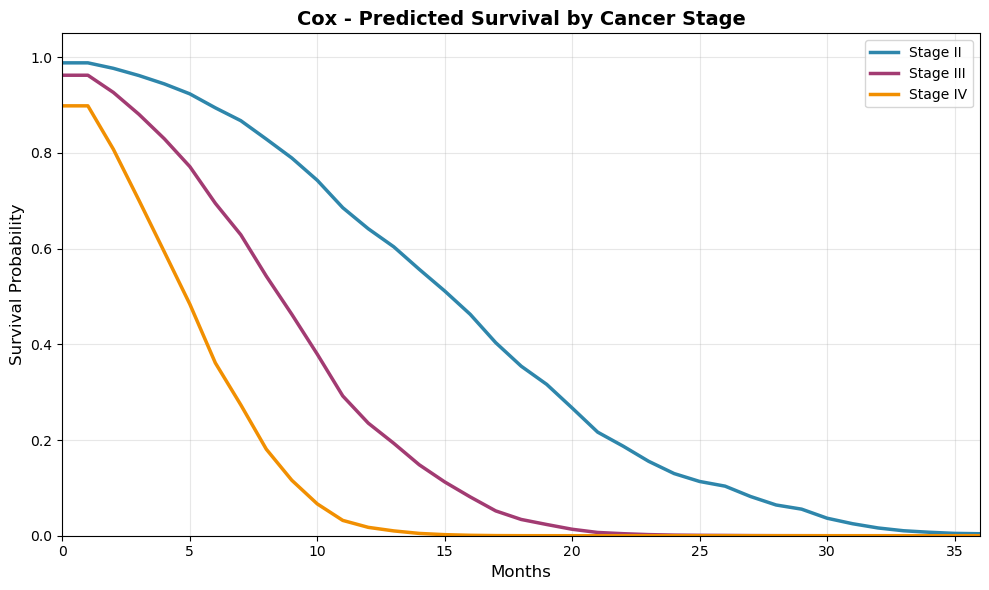


--- SURVIVAL PROBABILITIES ---

Stage II:
  6 months: 0.894 (89.4%)
  12 months: 0.642 (64.2%)
  18 months: 0.354 (35.4%)
  24 months: 0.130 (13.0%)

Stage III:
  6 months: 0.695 (69.5%)
  12 months: 0.235 (23.5%)
  18 months: 0.034 (3.4%)
  24 months: 0.001 (0.1%)

Stage IV:
  6 months: 0.361 (36.1%)
  12 months: 0.017 (1.7%)
  18 months: 0.000 (0.0%)
  24 months: 0.000 (0.0%)

--- RISK SCORES (higher = worse) ---
  Stage II: 0.392
  Stage III: 1.278
  Stage IV: 3.575


In [8]:
# 7. PREDICTIONS FOR NEW PATIENTS

print("PREDICTIONS FOR NEW PATIENTS")

new = pd.DataFrame({"Cancer_Stage": ["Stage II", "Stage III", "Stage IV"]})

for col in categorical_cols:
    if col not in new.columns and col != "Cancer_Stage":
        new[col] = data_scaled[col].mode().iloc[0]

for col in numeric_cols:
    if col not in new.columns:
        new[col] = 0

surv = final_model.predict_survival_function(new, times=np.arange(0, 37, 1))

plt.figure(figsize=(10, 6))
colors = ["#2E86AB", "#A23B72", "#F18F01"]
stages = ["Stage II", "Stage III", "Stage IV"]

for i in range(3):
    surv[i].plot(label=stages[i], color=colors[i], linewidth=2.5)

plt.title("Cox - Predicted Survival by Cancer Stage", fontsize=14, fontweight="bold")
plt.xlabel("Months", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)
plt.xlim(0, 36)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- SURVIVAL PROBABILITIES ---")
times = [6, 12, 18, 24]

for i in range(3):
    print(f"\n{stages[i]}:")
    for t in times:
        prob = surv[i].loc[t] if t in surv[i].index else surv[i].iloc[-1]
        print(f"  {t} months: {prob:.3f} ({prob*100:.1f}%)")

risk_new = final_model.predict_partial_hazard(new)
print(f"\n--- RISK SCORES (higher = worse) ---")
for i in range(3):
    print(f"  {stages[i]}: {risk_new.iloc[i]:.3f}")


In [9]:
# 8. RESULTS TABLE

print("GRID SEARCH RESULTS")

results_df = pd.DataFrame(results, columns=["penalizer", "l1_ratio", "C-index", "std"])
results_pivot = results_df.pivot(index="penalizer", columns="l1_ratio", values="C-index")

print("\nC-index for different penalizer and l1_ratio values:")
print(results_pivot.round(3))

print(f"\nBEST: penalizer={best_penalizer}, l1_ratio={best_l1_ratio}, C-index={best_score:.3f}")

GRID SEARCH RESULTS

C-index for different penalizer and l1_ratio values:
l1_ratio     0.0    0.5
penalizer              
0.01       0.792  0.791
0.10       0.784  0.781

BEST: penalizer=0.01, l1_ratio=0.0, C-index=0.792


In [10]:
# 9. CONCLUSION
print("=" * 70)
print("CONCLUSION")
print("=" * 70)
print(f"""
     BEST COX MODEL:
   - penalizer = {best_penalizer}
   - l1_ratio = {best_l1_ratio}
   - CV C-index = {best_score:.3f} (+/- {results_df[results_df['C-index'] == best_score]['std'].values[0]:.3f})

     INTERPRETATION:
   - C-index = {best_score:.3f} means the model correctly ranks 
     patient pairs {best_score*100:.1f}% of the time
   - This is an EXCELLENT discriminative ability for clinical use

     RISK GROUPS FOR {len(alive)} ALIVE PATIENTS:
   - Low Risk: {risk_stats.loc['Low Risk', ('Risk_Score', 'count')]} patients,
     avg survival {risk_stats.loc['Low Risk', ('Survival_Months', 'mean')]:.1f} months
   - Intermediate Risk: {risk_stats.loc['Intermediate Risk', ('Risk_Score', 'count')]} patients,
     avg survival {risk_stats.loc['Intermediate Risk', ('Survival_Months', 'mean')]:.1f} months
   - High Risk: {risk_stats.loc['High Risk', ('Risk_Score', 'count')]} patients,
     avg survival {risk_stats.loc['High Risk', ('Survival_Months', 'mean')]:.1f} months

   CLINICAL UTILITY:
   The model successfully stratifies patients into 3 distinct risk groups
   with clinically meaningful survival differences.
""")


CONCLUSION

     BEST COX MODEL:
   - penalizer = 0.01
   - l1_ratio = 0.0
   - CV C-index = 0.792 (+/- 0.005)

     INTERPRETATION:
   - C-index = 0.792 means the model correctly ranks 
     patient pairs 79.2% of the time
   - This is an EXCELLENT discriminative ability for clinical use

     RISK GROUPS FOR 238 ALIVE PATIENTS:
   - Low Risk: 79 patients,
     avg survival 60.4 months
   - Intermediate Risk: 78 patients,
     avg survival 27.9 months
   - High Risk: 81 patients,
     avg survival 10.5 months

   CLINICAL UTILITY:
   The model successfully stratifies patients into 3 distinct risk groups
   with clinically meaningful survival differences.

